In [34]:
import os
import pandas as pd
from lifelines import CoxPHFitter
from datetime import datetime 
import duckdb
import unicodedata
import sys
from pathlib import Path
from kedro.framework.startup import bootstrap_project
from kedro.framework.session import KedroSession

# 1. Move to project root if we are in the notebooks folder
if Path.cwd().name == "notebooks":
    os.chdir("..")

# 2. Initialize Kedro
project_path = Path.cwd()
bootstrap_project(project_path)

# 3. Create session and get catalog
session = KedroSession.create(project_path)
context = session.load_context()
catalog = context.catalog

print(f"✅ Kedro context loaded! Project root: {project_path}")

[06/23/26 17:52:10] INFO     Kedro is sending anonymous usage data with the sole purpose of improving ]8;id=276490;file://c:\Users\User\miniconda3\envs\unis\Lib\site-packages\kedro_telemetry\plugin.py\plugin.py]8;;\:]8;id=470210;file://c:\Users\User\miniconda3\envs\unis\Lib\site-packages\kedro_telemetry\plugin.py#242\242]8;;\
                             the product. No personal data or IP addresses are stored on our side. To              
                             opt out, set the `KEDRO_DISABLE_TELEMETRY` or `DO_NOT_TRACK` environment              
                             variables, or create a `.telemetry` file in the current working                       
                             directory with the contents `consent: false`. To hide this message,                   
                             explicitly grant or deny consent. Read more at                                        
                             https://docs.kedro.org/en/stable/about/telemetry/                                     

✅ Kedro context loaded! Project root: g:\Unidades compartidas\Alianzas\3. Data\UNIS\unis-perm-flow


In [35]:
# Add the 'src' directory to the path
sys.path.append(os.path.abspath("src"))
import unis_perm_flow.pipelines.data_processing.nodes as nodes_dproc
import unis_perm_flow.pipelines.calac_activos_baj_grad.nodes as nodes_abg

# Cargar datos

In [36]:
df  = catalog.load('unis_estados_calac_survival')
# --- Preparación del Modelo de Cox ---
# Seleccionamos las columnas necesarias para el modelo y la identificación posterior
columnas_interes = ['identificacion', 'periodo_inicial', 'nivel', 'programa', 'month', 'di']
df_modelo = df[columnas_interes].copy()
# En Python (lifelines), el modelo requiere variables numéricas (dummies)
# Para simular relevel(ref = "marketing digital"), usamos drop_first o creamos dummies manualmente.
# Como solo usas 'programa' en la fórmula, creamos sus dummies:
df_dummies = pd.get_dummies(df_modelo['programa'], prefix='prog')
# Definimos la referencia eliminando la columna de 'marketing digital'
col_referencia = 'prog_marketing digital'
if col_referencia in df_dummies.columns:
    df_dummies = df_dummies.drop(columns=[col_referencia])

# Concatenamos las dummies al dataframe de trabajo
df_cox = pd.concat([df_modelo[['month', 'di']], df_dummies], axis=1)
# 3. Ajustar el modelo de Cox
best_model = CoxPHFitter()
best_model.fit(df_cox, duration_col='month', event_col='di')



[06/23/26 17:52:11] INFO     Loading data from unis_estados_calac_survival (ParquetDataset)... ]8;id=431177;file://c:\Users\User\miniconda3\envs\unis\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=592103;file://c:\Users\User\miniconda3\envs\unis\Lib\site-packages\kedro\io\data_catalog.py#1048\1048]8;;\

<lifelines.CoxPHFitter: fitted with 1826 total observations, 1215 right-censored observations>

# Importar modelo

In [38]:
best_model = catalog.load('modelo_cox_desercion')

[06/23/26 17:52:51] INFO     Loading data from modelo_cox_desercion (PickleDataset)...         ]8;id=927828;file://c:\Users\User\miniconda3\envs\unis\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=850575;file://c:\Users\User\miniconda3\envs\unis\Lib\site-packages\kedro\io\data_catalog.py#1048\1048]8;;\

In [39]:
best_model.print_summary()

<lifelines.CoxPHFitter: fitted with 1826 total observations, 1215 right-censored observations>
             duration col = 'month'
                event col = 'di'
      baseline estimation = breslow
   number of observations = 1826
number of events observed = 611
   partial log-likelihood = -4326.33
         time fit was run = 2026-06-23 22:50:59 UTC

---
                                coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                          
prog_neuropsicologia clinica    0.30      1.35      0.13            0.04            0.56                1.04                1.75
prog_docencia universitaria     0.46      1.59      0.13            0.21            0.71                1.24                2.03
prog_administracion financiera  0.63      1.87      0.24            0.16            1.10                1.17                3.00
prog_talento humano             0.35      1.42      0.27           -0.18            0.87                0.84                2.39
prog_direccion financiera       0.03      1.03      0.20           -0.36            0.42                0.70                1.53
prog_ciberseguridad            -1.58      0.21      1.01           -3.55            0.40                0.03                1.49
prog_gestion talento humano     0.08      1.09      0.72           -1.32            1.49                0.27                4.44

                                cmp to     z      p  -log2(p)
covariate                                                    
prog_neuropsicologia clinica      0.00  2.29   0.02      5.51
prog_docencia universitaria       0.00  3.65 <0.005     11.88
prog_administracion financiera    0.00  2.62   0.01      6.82
prog_talento humano               0.00  1.30   0.19      2.37
prog_direccion financiera         0.00  0.16   0.87      0.19
prog_ciberseguridad               0.00 -1.57   0.12      3.09
prog_gestion talento humano       0.00  0.12   0.91      0.14
---
Concordance = 0.55
Partial AIC = 8666.66
log-likelihood ratio test = 26.86 on 7 df
-log2(p) of ll-ratio test = 11.47

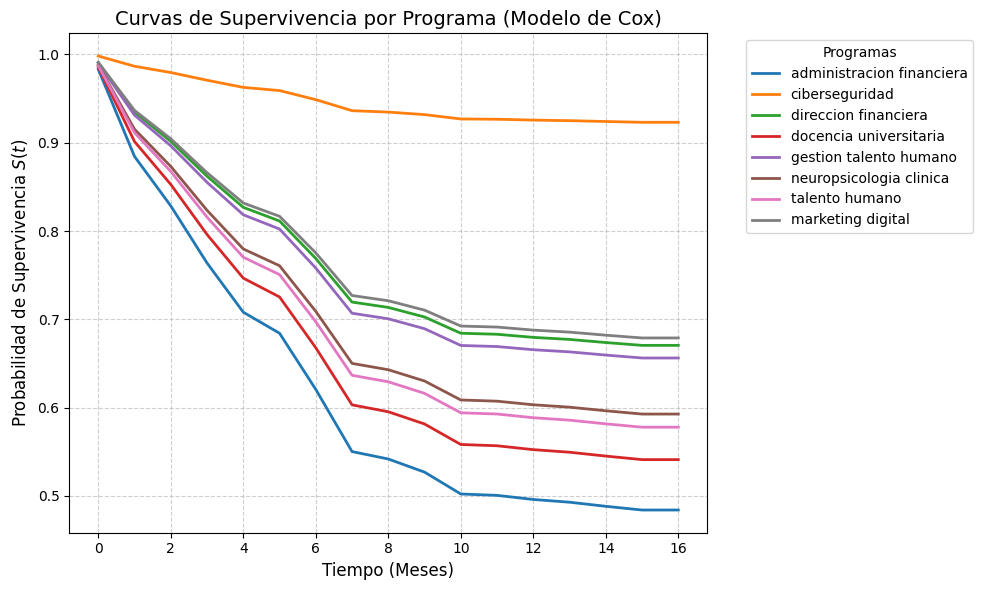

In [28]:
import matplotlib.pyplot as plt

# 1. Obtener la lista de las columnas dummy reales que tiene tu modelo entrenado
columnas_modelo_dummies = [col for col in df_cox.columns if col not in ['month', 'di']]

# 2. Crear una matriz de prueba para predecir (una fila por cada programa existente)
# Primero incluimos los programas que tienen dummy propia
df_curvas_pred = pd.DataFrame(0, index=columnas_modelo_dummies, columns=columnas_modelo_dummies)
for col in columnas_modelo_dummies:
    df_curvas_pred.loc[col, col] = 1

# Añadimos la fila de la referencia (Marketing Digital) donde todas las dummies son 0
fila_referencia = pd.DataFrame(0, index=['prog_marketing digital'], columns=columnas_modelo_dummies)
df_curvas_pred = pd.concat([df_curvas_pred, fila_referencia])

# 3. Predecir la supervivencia para todos los programas
curvas_supervivencia = best_model.predict_survival_function(df_curvas_pred)

# Limpiamos los nombres de las columnas para el gráfico (quitar el prefijo 'prog_')
curvas_supervivencia.columns = [col.replace('prog_', '') for col in curvas_supervivencia.columns]

# 4. Graficar curvas de supervivencia
plt.figure(figsize=(10, 6))
for programa in curvas_supervivencia.columns:
    plt.plot(curvas_supervivencia.index, curvas_supervivencia[programa], label=programa, linewidth=2)

plt.title('Curvas de Supervivencia por Programa (Modelo de Cox)', fontsize=14)
plt.xlabel('Tiempo (Meses)', fontsize=12)
plt.ylabel('Probabilidad de Supervivencia $S(t)$', fontsize=12)
plt.legend(title="Programas", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

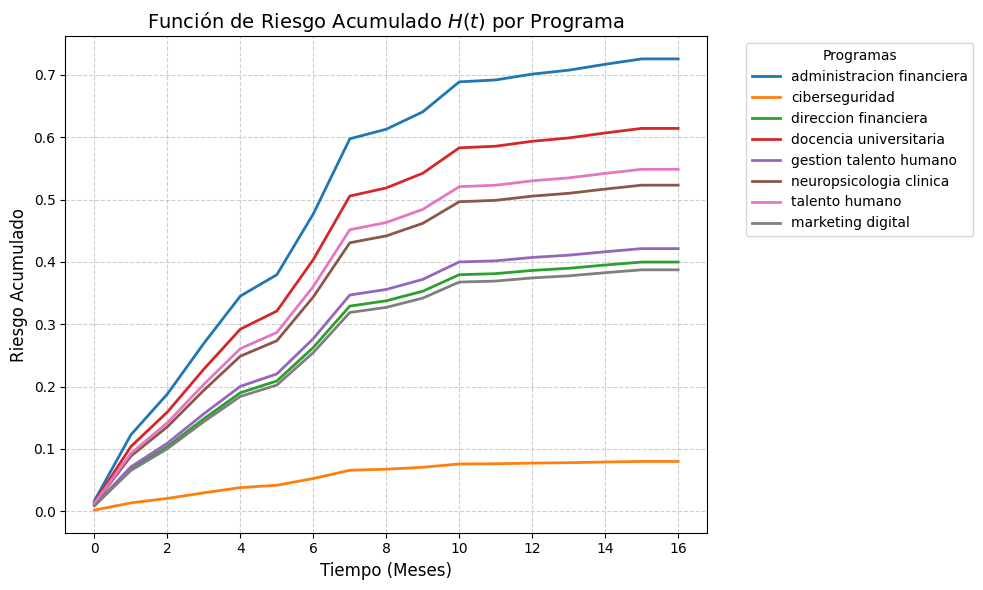

In [33]:
# 1. Predecir el riesgo acumulado utilizando la misma matriz estructurada
curvas_hazard = best_model.predict_cumulative_hazard(df_curvas_pred)

# Limpiamos los nombres de las columnas (quitar el prefijo 'prog_')
curvas_hazard.columns = [col.replace('prog_', '') for col in curvas_hazard.columns]

# 2. Graficar curvas de riesgo acumulado
plt.figure(figsize=(10, 6))
for programa in curvas_hazard.columns:
    plt.plot(curvas_hazard.index, curvas_hazard[programa], label=programa, linewidth=2)

plt.title('Función de Riesgo Acumulado $H(t)$ por Programa', fontsize=14)
plt.xlabel('Tiempo (Meses)', fontsize=12)
plt.ylabel('Riesgo Acumulado', fontsize=12)
plt.legend(title="Programas", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [29]:
# 4. Obtener las curvas de supervivencia individualizadas
# 'predict_survival_function' devuelve un DataFrame donde:
# Índices (filas) = Tiempos en meses
# Columnas = Índices de los estudiante
surv_matrix = best_model.predict_survival_function(df_cox)

In [14]:
# 5. Extraer probabilidades para los meses_evaluar (1 a 16)
meses_evaluar = list(range(1, 17))

In [15]:
# Reindexamos para asegurar que tenemos exactamente los meses del 1 al 16.
# ffill() emula el 'extend = TRUE' de R (mantiene el último valor conocido si el mes exacto no tuvo eventos)
# bfill() asegura que si el mes 1 no está explícito, herede el 100% (1.0) del mes 0
surv_matrix_eval = surv_matrix.reindex(meses_evaluar).ffill().bfill()


In [16]:
# --- Reconstrucción del dataset final en formato largo (Unnest) ---
# Reseteamos el índice de la matriz para tener 'mes' como columna y pivoteamos a formato largo
surv_matrix_long = surv_matrix_eval.reset_index().rename(columns={'index': 'mes'})
surv_matrix_long = pd.melt(surv_matrix_long, id_vars=['mes'], var_name='estudiante_idx', value_name='p_sobrevivir')

In [17]:
# Aseguramos que los tipos coincidan para hacer el cruce final
surv_matrix_long['estudiante_idx'] = surv_matrix_long['estudiante_idx'].astype(int)

# 6. Unir con las variables llave originales de df
df_probabilidades = df_modelo.reset_index(drop=True)
df_probabilidades['estudiante_idx'] = df_probabilidades.index

# Combinar todo para obtener el formato largo final por estudiante y mes
df_probabilidades = pd.merge(surv_matrix_long, df_probabilidades, on='estudiante_idx')

# Reordenar columnas para que quede idéntico a tu output de R
df_probabilidades = df_probabilidades[['identificacion', 'periodo_inicial', 'nivel', 'programa', 'month', 'di', 'p_sobrevivir', 'mes']]

# Visualizar el resultado final
print(df_probabilidades.head())

   identificacion  periodo_inicial     nivel                 programa  month  \
0    1.622559e+12           9243.0  maestria  neuropsicologia clinica      1   
1    1.622559e+12           9243.0  maestria  neuropsicologia clinica      1   
2    1.622559e+12           9243.0  maestria  neuropsicologia clinica      1   
3    1.622559e+12           9243.0  maestria  neuropsicologia clinica      1   
4    1.622559e+12           9243.0  maestria  neuropsicologia clinica      1   

   di  p_sobrevivir  mes  
0   1      0.915261    1  
1   1      0.873134    2  
2   1      0.823446    3  
3   1      0.779711    4  
4   1      0.760697    5  


In [18]:
df_probabilidades['programa'].unique()


array(['neuropsicologia clinica', 'docencia universitaria',
       'marketing digital', 'administracion financiera', 'talento humano',
       'direccion financiera', 'ciberseguridad', 'gestion talento humano'],
      dtype=object)

In [21]:
df_probabilidades

,identificacion,periodo_inicial,nivel,programa,month,di,p_sobrevivir,mes
0,1.622559e+12,9243.0,maestria,neuropsicologia clinica,1,1,0.915261,1
1,1.622559e+12,9243.0,maestria,neuropsicologia clinica,1,1,0.873134,2
2,1.622559e+12,9243.0,maestria,neuropsicologia clinica,1,1,0.823446,3
3,1.622559e+12,9243.0,maestria,neuropsicologia clinica,1,1,0.779711,4
4,1.622559e+12,9243.0,maestria,neuropsicologia clinica,1,1,0.760697,5
...,...,...,...,...,...,...,...,...
29211,3.619254e+12,9262.0,maestria,neuropsicologia clinica,2,0,0.603261,12
29212,3.619254e+12,9262.0,maestria,neuropsicologia clinica,2,0,0.600543,13
29213,3.619254e+12,9262.0,maestria,neuropsicologia clinica,2,0,0.596468,14
29214,3.619254e+12,9262.0,maestria,neuropsicologia clinica,2,0,0.592756,15


# Proyecciones

In [30]:
import pandas as pd
import numpy as np

# ==============================================================================
# 1. LISTA COMPLETA DE PROGRAMAS DEL MODELO ORIGINAL
# ==============================================================================
programas_originales = [
    'neuropsicologia clinica', 'docencia universitaria', 'marketing digital', 
    'administracion financiera', 'talento humano', 'direccion financiera', 
    'ciberseguridad', 'gestion talento humano'
]

# Definimos los nuevos ingresos operacionales (solo te interesan estos dos para proyectar)
nuevos_estudiantes = pd.DataFrame({
    'programa': ['marketing digital', 'administracion financiera'],
    'n_inicial': [150, 120]
})

# ==============================================================================
# 2. CONSTRUIR LA MATRIZ DE PREDICCIÓN CON TODAS LAS DUMMIES ORIGINALES
# ==============================================================================
# Creamos un DataFrame vacío que tendrá una fila por cada programa que queremos proyectar
# y una columna por cada variable dummy que el modelo 'best_model' espera recibir.
programas_a_proyectar = nuevos_estudiantes['programa'].tolist()

# Construimos la estructura idéntica de dummies que vio el modelo al entrenarse
columnas_dummies = [f'prog_{p}' for p in programas_originales if p != 'marketing digital']
df_pred_dummies = pd.DataFrame(0, index=range(len(programas_a_proyectar)), columns=columnas_dummies)

# Activamos el "1" en la dummy correspondiente para cada programa a proyectar
for i, prog in enumerate(programas_a_proyectar):
    col_name = f'prog_{prog}'
    if col_name in df_pred_dummies.columns:
        df_pred_dummies.loc[i, col_name] = 1
    # Si el programa es 'marketing digital', todas sus dummies se quedan en 0 (es la referencia)


In [31]:

# ==============================================================================
# 3. OBTENER LAS PREDICCIONES DEL MODELO DE COX
# ==============================================================================
# 'best_model' ahora recibe la estructura perfecta con todas las variables del modelo original
pred_cox = best_model.predict_survival_function(df_pred_dummies)

# Definimos el horizonte de meses a evaluar (del mes 1 al máximo del set original)
max_meses = int(df['month'].max())
meses_evaluar = list(range(1, max_meses + 1))

# Reindexamos y aplicamos forward-fill / backward-fill para construir la escalera continua
tabla_superv_base = pred_cox.reindex(meses_evaluar).ffill().bfill()

# Pasamos a formato largo (melt)
tabla_superv_base = tabla_superv_base.reset_index().rename(columns={'index': 'mes'})
tabla_superv_base = pd.melt(tabla_superv_base, id_vars=['mes'], var_name='programa_idx', value_name='p_sobrevivir')

# Mapeamos los índices numéricos de la predicción a los nombres de los programas reales
tabla_superv_base['programa'] = tabla_superv_base['programa_idx'].map(pd.Series(programas_a_proyectar))

# ==============================================================================
# 4. CALCULAR LA TABLA DE VIDA PROYECTADA (Totales Esperados)
# ==============================================================================
tabla_vida_nuevos = pd.merge(nuevos_estudiantes, tabla_superv_base, on='programa')

# Cálculos de la población esperada
tabla_vida_nuevos['estudiantes_esperados_activos'] = tabla_vida_nuevos['n_inicial'] * tabla_vida_nuevos['p_sobrevivir']
tabla_vida_nuevos['estudiantes_esperados_redond'] = tabla_vida_nuevos['estudiantes_esperados_activos'].round().astype(int)
tabla_vida_nuevos['desertores_acumulados_esperados'] = tabla_vida_nuevos['n_inicial'] - tabla_vida_nuevos['estudiantes_esperados_redond']

# Seleccionar y ordenar las columnas finales
tabla_vida_nuevos = tabla_vida_nuevos[[
    'programa', 'mes', 'n_inicial', 'p_sobrevivir', 
    'estudiantes_esperados_redond', 'desertores_acumulados_esperados'
]].sort_values(by=['programa', 'mes']).reset_index(drop=True)

print(tabla_vida_nuevos.head(20))

                     programa  mes  n_inicial  p_sobrevivir  \
0   administracion financiera    1        120      0.884415   
1   administracion financiera    2        120      0.828454   
2   administracion financiera    3        120      0.763784   
3   administracion financiera    4        120      0.708096   
4   administracion financiera    5        120      0.684256   
5   administracion financiera    6        120      0.620640   
6   administracion financiera    7        120      0.550274   
7   administracion financiera    8        120      0.541873   
8   administracion financiera    9        120      0.527011   
9   administracion financiera   10        120      0.502262   
10  administracion financiera   11        120      0.500703   
11  administracion financiera   12        120      0.496045   
12  administracion financiera   13        120      0.492947   
13  administracion financiera   14        120      0.488313   
14  administracion financiera   15        120      0.48

In [32]:
tabla_vida_nuevos

,programa,mes,n_inicial,p_sobrevivir,estudiantes_esperados_redond,desertores_acumulados_esperados
0,administracion financiera,1,120,0.884415,106,14
1,administracion financiera,2,120,0.828454,99,21
2,administracion financiera,3,120,0.763784,92,28
3,administracion financiera,4,120,0.708096,85,35
4,administracion financiera,5,120,0.684256,82,38
5,administracion financiera,6,120,0.620640,74,46
6,administracion financiera,7,120,0.550274,66,54
7,administracion financiera,8,120,0.541873,65,55
8,administracion financiera,9,120,0.527011,63,57
9,administracion financiera,10,120,0.502262,60,60
